
# Ex 2 Visualizing ADAM Optimization on a Simple Polynomial Cost Function

This notebook demonstrates how the ADAM optimizer performs on a simple 2D polynomial cost function with multiple local minima.

We'll define a cost function with several quadratic basins and show how ADAM, thanks to its momentum and adaptive step sizes, efficiently finds a minimum without getting stuck in local traps.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


**bold text**
## The Cost Function

This is the cost function from the previous tutorial


In [ ]:
def m_and_grad_numpy(x, alpha=1.0):
    x1, x2 = x # input
    # z function  and its Jacobian
    # (see the computational graph in BB)
    z = np.array([
        x2,
        3 * x1**2 - x2,
        4 * x1 - x2**3
    ])
    dz_dx = np.array([
        [],
        [],
        []
    ])

    # l function and its Jacobian (see graph)
    l = np.array([np.sum(z**2), np.sum(z)])
    dl_dz = np.array([
        [ ],
        []
    ])
    # g function and its Jacobian (see graph)
    g = np.array([x1 + x2, x1**2 - x2**2])
    dg_dx = np.array([
        [, ],
        [, ]
    ])
    # m function and its Jacobian (see graph)
    m = np.sum(l**2) + alpha * np.sum(g**2)
    grad_m= 2 * l @ dl_dz @ dz_dx + 2 * alpha * g @ dg_dx
    return m, grad_m

In [ ]:
def adam_optimize(func, x0, lr=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8, max_iter=1000, tol=1e-6, **kwargs):
    """
    ADAM optimization to minimize a callable function with a cost and gradient.

    Parameters:
    -----------
    func : callable
        A function that returns a tuple (J(x), grad J(x)), where J is the cost and grad J is the gradient.

    x0 : numpy array
        Initial guess for the parameter vector.

    lr : float
        Learning rate for the ADAM optimizer.

    beta1 : float
        Exponential decay rate for the first moment estimate.

    beta2 : float
        Exponential decay rate for the second moment estimate.

    epsilon : float
        Small constant to avoid division by zero.

    max_iter : int
        Maximum number of iterations.

    tol : float
        Tolerance for convergence.

    **kwargs : dict
        Extra arguments passed to the function `func(x, **kwargs)`.

    Returns:
    --------
    result : dict
        Dictionary containing:
            - x: Final optimized parameters
            - final_cost: Cost at the solution
            - iterations: Number of iterations performed
            - converged: Whether convergence criterion was met
            - history: Dictionary with 'costs' and 'parameters' over iterations
    """
    x = np.array(x0, dtype=np.float64)
    m = np.zeros_like(x)
    v = np.zeros_like(x)
    t = 0  # iteration counter

    history = {
        "costs": [],
        "parameters": []
    }

    for _ in tqdm(range(max_iter), desc="Optimizing with ADAM"):
        t += 1
        J, grad = func(x, **kwargs)
        history["costs"].append(J)
        history["parameters"].append(x.copy())

        # Update biased moment estimates
        m = beta1 * m + (1 - beta1) * grad
        v =

        # Bias correction
        m_hat =
        v_hat =

        # Update parameters
        x_prev = x
        x = x - lr * m_hat / (np.sqrt(v_hat) + epsilon)

        # Check convergence
        if np.linalg.norm(x - x_prev) < tol:
            return {
                "x": x,
                "final_cost": J,
                "iterations": t,
                "converged": True,
                "history": history
            }

    return {
        "x": x,
        "final_cost": J,
        "iterations": max_iter,
        "converged": False,
        "history": history
    }


In [ ]:
# Run optimizer
result = adam_optimize(m_and_grad_numpy, x0=np.array([-3.0, -3.0]),lr=0.2,max_iter=10000)
x_opt = result["x"]
cost_min = result["final_cost"]
history = result["history"]

print(f"Optimal point found: {x_opt}")
print(f"Final cost: {cost_min}")
print(f"Converged: {result['converged']} in {result['iterations']} iterations")

Optimizing with ADAM: 100%|██████████| 10000/10000 [00:00<00:00, 13157.46it/s]

Optimal point found: [ 0.00363555 -0.05999256]
Final cost: 0.0034688704378596927
Converged: False in 10000 iterations


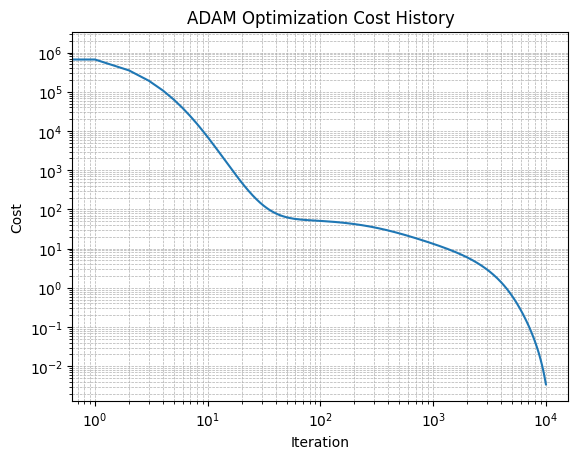

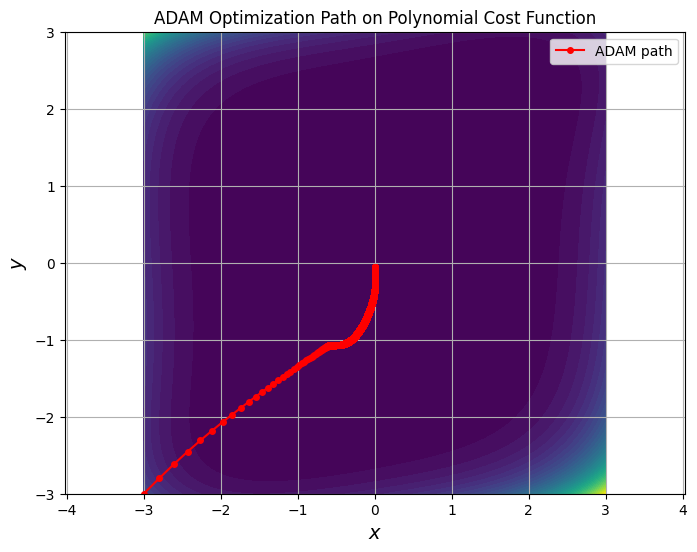

In [ ]:

params = np.array(history["parameters"])

# Plot cost history
plt.figure()
plt.plot(history["costs"])
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.yscale("log")  # log scale for better visibility of convergence
plt.xscale("log")  # log scale for better visibility of convergence
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.title("ADAM Optimization Cost History")
plt.grid(True)
plt.show()

x1_vals = np.linspace(-3, 3, 300)
x2_vals = np.linspace(-3, 3, 300)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
M = np.zeros_like(X1)

for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        x = np.array([X1[i, j], X2[i, j]])
        m_val, grad_val = m_and_grad_numpy(x)
        M[i, j] = m_val


# Plot contour and path
plt.figure(figsize=(8, 6))
cp = plt.contourf(X1, X2, M, levels=40, cmap='viridis')
plt.plot(params[:, 0], params[:, 1], 'o-', color='red', markersize=4, label='ADAM path')
plt.xlabel('$x$', fontsize=14)
plt.ylabel('$y$', fontsize=14)
plt.title('ADAM Optimization Path on Polynomial Cost Function')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()